# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name:  
Created by NAMES (SJSU IDs)  
Last updated: DATE  

### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

The dataset is relatively well-structured, but there are some important data quality issues. The main concern is the presence of a large number of missing values in key numerical columns such as units reimbursed, number of prescriptions, and reimbursement amounts. These missing values are likely due to data suppression for privacy reasons, as indicated by the "Suppression Used" column.

To clean the data, we plan to remove rows where suppression is marked as true or where important numerical values are missing. We will also filter out any invalid or non-positive values to ensure accuracy in our analysis. Overall, while the dataset is usable, careful filtering and cleaning are required before performing any meaningful analysis.

### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

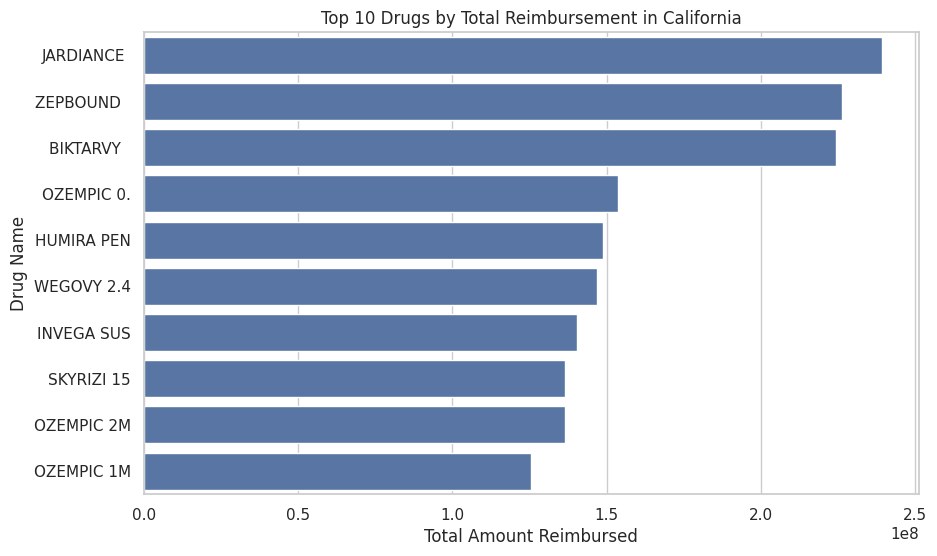

In [1]:
# Your code here . . .

# Question: Which drugs have the highest total reimbursement in CA

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = pd.read_csv("https://download.medicaid.gov/data/sdud-2025-updated-dec2025.csv")

# filter only California and clean data
ca_df = df[
    (df['State'] == 'CA') &
    (df['Suppression Used'] == False)
].dropna(subset=['Total Amount Reimbursed'])

# combine  total reimbursement by drug
top_drugs = (
    ca_df.groupby('Product Name')['Total Amount Reimbursed']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_drugs,
    x='Total Amount Reimbursed',
    y='Product Name'
)

plt.title("Top 10 Drugs by Total Reimbursement in California")
plt.xlabel("Total Amount Reimbursed")
plt.ylabel("Drug Name")
plt.show()

### Q3: Come up with a another unique question. This question must use map() or apply()

In [2]:
# Your code here . . .

#Question: How can we categorize drug spending tiers like low medium or high

# Create spending tiers
def spending_category(x):
    if x < 1e5:
        return "Low"
    elif x < 1e6:
        return "Medium"
    else:
        return "High"

df_clean = df[
    (df['Suppression Used'] == False)
].dropna(subset=['Total Amount Reimbursed'])

df_clean['Spending Category'] = df_clean['Total Amount Reimbursed'].apply(spending_category)

# Count how many drugs fall into each category
category_counts = df_clean['Spending Category'].value_counts()

print(category_counts)

Spending Category
Low       1233552
Medium      64992
High        14853
Name: count, dtype: int64


### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

In [6]:
# Your code here . . .




## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?



To strengthen our analysis, we could use additional datasets such as U.S. Census population data by state. This would allow us to normalize prescription counts and reimbursement amounts per capita, making comparisons between states more meaningful. We could also include a dataset that classifies drugs into categories (such as diabetes, pain management, or mental health) to better understand which types of drugs are driving costs. Another useful dataset could be political affiliation by state (red vs blue states) to explore differences in healthcare spending patterns.

We would combine these datasets by merging them with our Medicaid dataset using the "State" column as the key. After merging, we could create new metrics such as prescriptions per capita or reimbursement per capita to improve our analysis.

We may also need to reshape the data by grouping it by state or drug category to calculate totals or averages. This could involve using groupby operations or pivot tables to organize the data in a way that is easier to visualize.

#Pseudocode

- Load Medicaid dataset
- Load additional dataset (e.g., population data)
- Merge datasets on "State"
- Create new calculated columns (per capita metrics)
- Group or aggregate data as needed
- Generate visualizations
